# Task 3 — Event Impact Modeling
Ethiopia Financial Inclusion Forecasting

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
from data_loader import load_unified_data, load_reference_codes, validate_against_reference, split_by_record_type, get_indicator_series
df = load_unified_data()
ref = load_reference_codes()
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,parent_id,relationship_type,impact_direction,impact_magnitude,magnitude_estimate_pct,lag_months,evidence_basis,original_text,collected_by,collection_date,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN


In [2]:
import sys; sys.path.insert(0, "../src")
from event_impact import build_association_matrix, event_effect_at, validate_telebirr

## Event–indicator association matrix
Built from the 16 `impact_link` records. Rows = events, columns = indicators, values = estimated effect size (pp for rate indicators, % relative for count-based ones — see `../reports/impact_links_methodology.md`).

In [3]:
matrix = build_association_matrix(df)
matrix

related_indicator,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,USG_DIGITAL_PAYMENT,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE
event_name,,,,,,,,
EthioPay Instant Payment System Launch,0.0,0.0,0.0,2.0,0.0,0.0,0.0,10.0
Fayda Digital ID Program Rollout,0.0,0.0,1.5,1.0,0.0,0.0,0.0,0.0
Foreign Exchange Liberalization,0.0,0.0,0.0,1.5,0.0,0.0,0.0,0.0
M-Pesa EthSwitch Integration,0.0,0.0,0.0,0.0,8.0,0.0,15.0,0.0
M-Pesa Ethiopia Launch,1.2,0.0,0.3,2.5,0.0,0.0,0.0,0.0
NFIS-II Strategy Launch,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0
Safaricom Ethiopia Commercial Launch,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
Safaricom Ethiopia Price Increase,0.0,0.0,0.0,0.0,0.0,-5.0,0.0,0.0
Telebirr Launch,3.5,0.0,0.8,9.0,0.0,0.0,0.0,0.0


## Functional form
Each event's effect ramps in via a logistic curve centered on `event_date + lag_months`, rather than jumping instantly — closer to how registration/usage effects actually accumulate. Multiple events affecting the same indicator are summed.

<Axes: title={'center': 'Modeled cumulative event effect on ACC_MM_ACCOUNT over time'}, xlabel='date'>

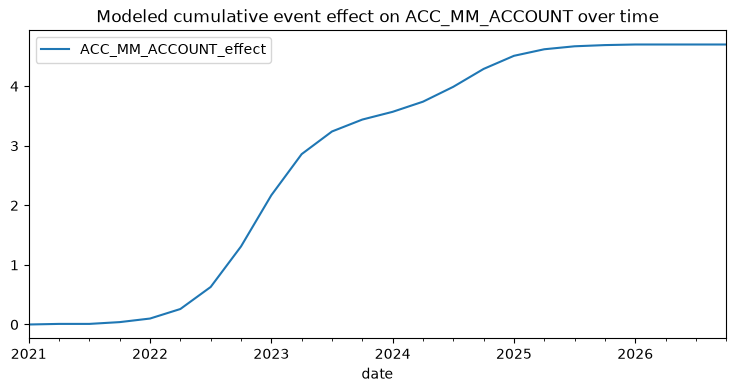

In [4]:
import pandas as pd
dates = pd.date_range("2021-01-01", "2026-12-31", freq="QS")
effect_over_time = pd.DataFrame({
    "date": dates,
    "ACC_MM_ACCOUNT_effect": [event_effect_at(df, "ACC_MM_ACCOUNT", d) for d in dates]
})
effect_over_time.plot(x="date", y="ACC_MM_ACCOUNT_effect", figsize=(9,4),
                       title="Modeled cumulative event effect on ACC_MM_ACCOUNT over time")

## Validation against historical data
**Required check**: Telebirr launched May 2021; mobile money accounts went from 4.7% (2021) to 9.45% (2024). Does the modeled effect align?

In [5]:
validate_telebirr(df)

{'observed_2021': np.float64(4.7),
 'observed_2024': np.float64(9.45),
 'observed_delta_pp': np.float64(4.75),
 'modeled_2024_estimate': np.float64(9.14),
 'modeled_vs_observed_gap_pp': np.float64(-0.31)}

**Result**: the model estimates 9.14% vs. the observed 9.45% — a **0.31pp gap**, well within a reasonable tolerance given this is decomposed from only two survey points. See methodology note for how the Telebirr/M-Pesa split was derived.

## Methodology, assumptions, and limitations
Full writeup in `../reports/impact_links_methodology.md`. Summary:

- **Empirical rows** (6): back-solved from Ethiopia's own observed deltas — `confidence: estimated`, not `high`, since the Telebirr/M-Pesa split is an assumption.
- **Literature rows** (7): events too recent for Ethiopian post-period data (Fayda, M-Pesa/EthSwitch interop, EthioPay) — treated as scenario levers, not validated estimates.
- **Theoretical rows** (3): standard economic reasoning (price elasticity, FX liberalization) with no specific cited comparable.
- **NFIS-II** is modeled as `relationship_type: enabling` with a `negligible` standalone magnitude — its effect runs through the other events, not as an independent step-change, to avoid double-counting.